<a href="https://colab.research.google.com/github/Ravi-Poddar26/colab/blob/master/kmean-cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import os
import pandas as pd
import numpy as np

In [6]:
import zipfile
from zipfile import ZipFile

# The path to the zip file
zip_file_path = "/content/customer_shopping_data.csv.zip"
# The directory where the contents should be extracted
extract_to_path = "/content/"

# Open the zip file in read mode ('r') using a context manager
with ZipFile(zip_file_path, 'r') as zip_ref:
  # Extract all the contents to the specified directory
  zip_ref.extractall(extract_to_path)


In [13]:
data = pd.read_csv("/content/drive/MyDrive/customer_shopping_data.csv")

In [14]:
data.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [15]:
data.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [16]:
data.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [19]:
df = data[['gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'shopping_mall']]

In [21]:
df.head()

,gender,age,category,quantity,price,payment_method,shopping_mall
0,Female,28,Clothing,5,1500.40,Credit Card,Kanyon
1,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul
2,Male,20,Clothing,1,300.08,Cash,Metrocity
3,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM
4,Female,53,Books,4,60.60,Cash,Kanyon


In [23]:
df['payment_method'].unique()

array(['Credit Card', 'Debit Card', 'Cash'], dtype=object)

In [56]:
for i in df['payment_method']:
  if i == 'Cash':
    continue
  else:
    df['payment_method'].replace(i, 'Online', inplace=True)


/tmp/ipykernel_9963/1710977255.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9963/1710977255.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [57]:
df.head()

,gender,age,category,quantity,price,payment_method,shopping_mall,cluster,payment_type
0,Female,28,Clothing,5,1500.40,Online,Kanyon,0,Online
1,Male,21,Shoes,3,1800.51,Online,Forum Istanbul,0,Online
2,Male,20,Clothing,1,300.08,Cash,Metrocity,1,Cash
3,Female,66,Shoes,5,3000.85,Online,Metropol AVM,0,Online
4,Female,53,Books,4,60.60,Cash,Kanyon,2,Cash


In [58]:
df['shopping_mall'].unique()

array(['Kanyon', 'Forum Istanbul', 'Metrocity', 'Metropol AVM',
       'Istinye Park', 'Mall of Istanbul', 'Emaar Square Mall',
       'Cevahir AVM', 'Viaport Outlet', 'Zorlu Center'], dtype=object)

In [59]:
df['payment_method'].unique()

array(['Online', 'Cash'], dtype=object)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          99457 non-null  object 
 1   age             99457 non-null  int64  
 2   category        99457 non-null  object 
 3   quantity        99457 non-null  int64  
 4   price           99457 non-null  float64
 5   payment_method  99457 non-null  object 
 6   shopping_mall   99457 non-null  object 
 7   cluster         99457 non-null  int32  
 8   payment_type    99457 non-null  object 
dtypes: float64(1), int32(1), int64(2), object(5)
memory usage: 6.4+ MB


In [62]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
num = df[['age', 'quantity', 'price']]
cat = df[['gender', 'category', 'payment_method', 'shopping_mall']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num.columns),
        ('cat', OneHotEncoder(handle_unknown='ignore',drop='first'), cat.columns)
    ]
)
X_processed = preprocessor.fit_transform(df)
print("Shape of processed data:", X_processed.shape)

Shape of processed data: (99457, 21)


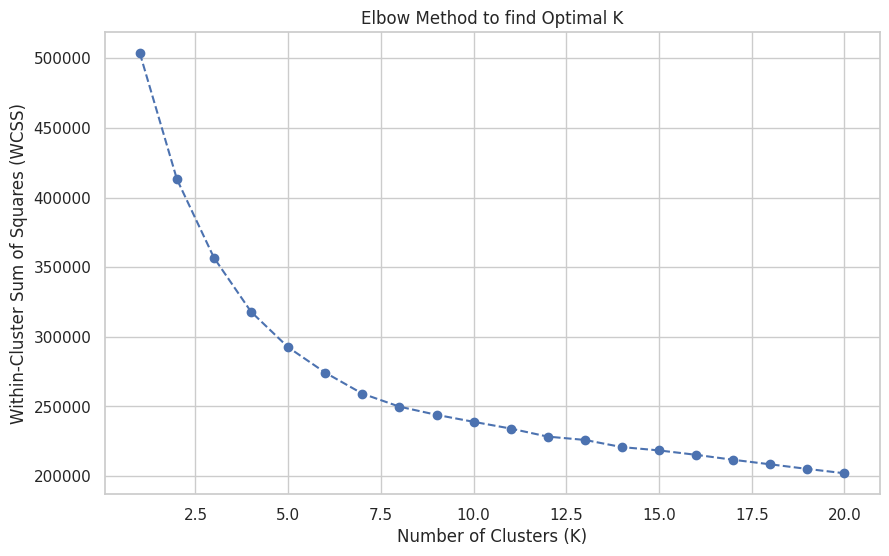

In [63]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Try different numbers of clusters from 1 to 10
for i in range(1, 21):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is set to suppress warning
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()


In [66]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_processed)

df.loc[:, 'cluster'] = cluster_labels

print(f"K-Means clustering applied with {optimal_k} clusters.")
display(df.head())

K-Means clustering applied with 3 clusters.


,gender,age,category,quantity,price,payment_method,shopping_mall,cluster,payment_type
0,Female,28,Clothing,5,1500.40,Online,Kanyon,2,Online
1,Male,21,Shoes,3,1800.51,Online,Forum Istanbul,2,Online
2,Male,20,Clothing,1,300.08,Cash,Metrocity,0,Cash
3,Female,66,Shoes,5,3000.85,Online,Metropol AVM,2,Online
4,Female,53,Books,4,60.60,Cash,Kanyon,1,Cash


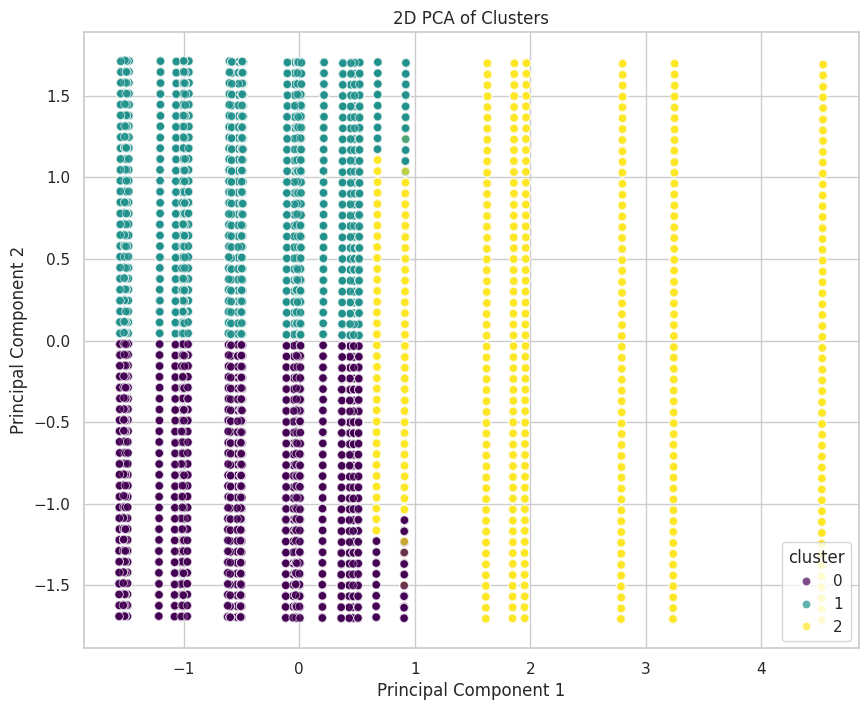

In [67]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# Apply PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Create a DataFrame for the PCA results with cluster labels
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['cluster'] = df['cluster']

# Visualize the clusters in 2D using the principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='cluster', data=pca_df, palette='viridis', legend='full', alpha=0.7)
plt.title('2D PCA of Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [68]:
import plotly.express as px

fig = px.scatter_3d(df, x='age', y='quantity', z='price', color='cluster',
                    title='3D Clusters of Customer Data',
                    color_continuous_scale=px.colors.sequential.Viridis)


fig.update_layout(scene = dict(
    xaxis_title='Age',
    yaxis_title='Quantity',
    zaxis_title='Price'
))

fig.show()

In [69]:
import pandas as pd

new_customer_data = pd.DataFrame({
    'gender': ['Female'],
    'age': [35],
    'category': ['Electronics'],
    'quantity': [2],
    'price': [750.00],
    'payment_method': ['Credit Card'],
    'shopping_mall': ['Mall of Istanbul']
})

print("New customer data:")
display(new_customer_data)

X_new_processed = preprocessor.transform(new_customer_data)

new_cluster_label = kmeans_final.predict(X_new_processed)

new_customer_data.loc[:, 'predicted_cluster'] = new_cluster_label[0]

print(f"\nThe new customer belongs to cluster: {new_cluster_label[0]}")
display(new_customer_data)

New customer data:


,gender,age,category,quantity,price,payment_method,shopping_mall
0,Female,35,Electronics,2,750.0,Credit Card,Mall of Istanbul



The new customer belongs to cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros



,gender,age,category,quantity,price,payment_method,shopping_mall,predicted_cluster
0,Female,35,Electronics,2,750.0,Credit Card,Mall of Istanbul,0


In [71]:
# Get the size of each cluster
print("Cluster sizes:")
display(df['cluster'].value_counts().sort_index())


Cluster sizes:


,count
cluster,
0,39642
1,39317
2,20498



Mean values of numerical features per cluster:


,age,quantity,price
cluster,,,
0,30.197341,2.671560,313.425479
1,56.864613,2.668718,323.933835
2,43.238316,4.287248,2116.813664



Distribution of categorical features per cluster:

gender distribution per cluster:


...

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
cluster,,,,,,,,
0,0.062736,0.297160,0.189698,0.189345,0.051662,0.063973,0.016523,0.128904
1,0.063433,0.295699,0.192716,0.184907,0.057634,0.062645,0.016380,0.126586
2,0.000000,0.540589,0.000000,0.000000,0.279052,0.000000,0.180359,0.000000



payment_method distribution per cluster:


payment_method,Cash,Online
cluster,,
0,0.446622,0.553378
1,0.447237,0.552763
2,0.446775,0.553225



shopping_mall distribution per cluster:


shopping_mall,Cevahir AVM,Emaar Square Mall,Forum Istanbul,Istinye Park,Kanyon,Mall of Istanbul,Metrocity,Metropol AVM,Viaport Outlet,Zorlu Center
cluster,,,,,,,,,,
0,0.051789,0.048030,0.049644,0.098961,0.197972,0.200015,0.149892,0.103678,0.050325,0.049695
1,0.048986,0.048300,0.050716,0.097286,0.199786,0.199583,0.152682,0.101178,0.048986,0.052496
2,0.049371,0.049176,0.048053,0.099180,0.200995,0.203288,0.149576,0.101132,0.048444,0.050785
